# Project 2 — Modified Shallow Water model: **LETKF vs 3D-Var** (OSSE)

A twin experiment (OSSE) with the 1D **Modified Shallow Water (MSW)** model over a
**bell-shaped mountain**. One nature run and one set of synthetic observations
(water height $h$ every 4th grid point) are assimilated with three DA methods:

| method | background covariance |
|---|---|
| **LETKF** | flow-dependent, ensemble ($N=50$), Gaspari–Cohn localization ($r=4$) |
| **3D-Var (Gauss B)** | *static*, block-diagonal, per-field variance × periodic Gaussian correlation ($L=5$) |
| **3D-Var (clim B)** | *static* sample covariance of the nature run, tapered by the same Gaussian correlation |

State vector: $\mathbf{x}=[\mathbf{u},\mathbf{h},\mathbf{r}]^\top\in\mathbb{R}^{3n}$, $n=100$.

**Deliverables:** per-field RMSE time series, time-mean RMSE table, LETKF spread–skill,
innovation statistics, final-time snapshots, and the two $B$ correlation structures.

> Requires `dapper`, plus the local `constants.py` and `msw_experiment_dapper.py`
> (the latter builds the HMM: dynamics + orography + stochastic forcing + obs operator).

## 0 · Imports and configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import dapper as dp
dp.rc.liveplotting = False          # notebook-safe
import dapper.da_methods as da

# Importing this module builds the HMM (dynamics + obs + chronology).
# It uses constants.py (n=100, mountain at x=50, h observed every 4th point).
import msw_experiment_dapper as msw
from constants import (n, nens, loc_radius, infl_factor,
                       sig, nth_point, obs_var_name)

plt.rcParams["figure.dpi"] = 110
FIELDS = ["u", "h", "r"]
SLICES = {"u": slice(0, n), "h": slice(n, 2*n), "r": slice(2*n, 3*n)}
COLORS = {"LETKF": "tab:blue",
          "3DVar (Gauss B)": "tab:red",
          "3DVar (clim B)": "tab:orange"}

print(f"n={n}, ensemble N={nens}, loc_rad={loc_radius}, infl={infl_factor}")
print(f"observing '{obs_var_name}' every {nth_point}th point")

n=100, ensemble N=50, loc_rad=4, infl=1.0

observing 'h' every 4th point

## 1 · Small helper functions
Field-wise RMSE / spread, and a periodic Gaussian correlation matrix used to build the static $B$.

In [2]:
def periodic_gauss_corr(n, L):
    '''(n x n) periodic Gaussian correlation, length scale L gridpoints.'''
    i = np.arange(n)
    d = np.abs(i[:, None] - i[None, :])
    d = np.minimum(d, n - d)                 # wrap-around distance
    return np.exp(-0.5 * (d / L) ** 2)

def rmse_per_field(err):
    '''err: (K, 3n) -> dict field -> (K,) RMSE.'''
    return {f: np.sqrt(np.mean(err[:, SLICES[f]] ** 2, axis=1)) for f in FIELDS}

def spread_per_field(spread):
    return {f: np.sqrt(np.mean(spread[:, SLICES[f]] ** 2, axis=1)) for f in FIELDS}

## 2 · Nature run and synthetic observations

`HMM.simulate()` integrates the MSW model to produce the **truth** `xx` and adds Gaussian
noise to the observed $h$ points to produce `yy`. The same `xx, yy` are fed to every method,
so differences are purely down to the DA scheme.

In [3]:
dp.set_seed(3000)
HMM  = msw.HMM
tseq = HMM.tseq

xx, yy = HMM.simulate()
yy = np.stack([np.asarray(y) for y in yy])   # DAPPER>=1.7 returns a list

tt_obs = tseq.tto                            # analysis/observation times
mask   = tt_obs > tseq.BurnIn                # keep only post burn-in cycles

print("truth xx:", xx.shape, " | obs yy:", yy.shape)
print(f"assimilation cycles: {len(tt_obs)}  (post burn-in: {mask.sum()})")

Truth & Obs:   0%|          | 0/1000 [00:00<?, ?it/s]

truth xx:

(1001, 300)

 | obs yy:

(50, 25)

assimilation cycles: 50  (post burn-in: 45)

### 2.1 · Hovmöller of the truth
The mountain sits at $x=50$; note the standing structure it imprints on $u$, $h$ and rain $r$.

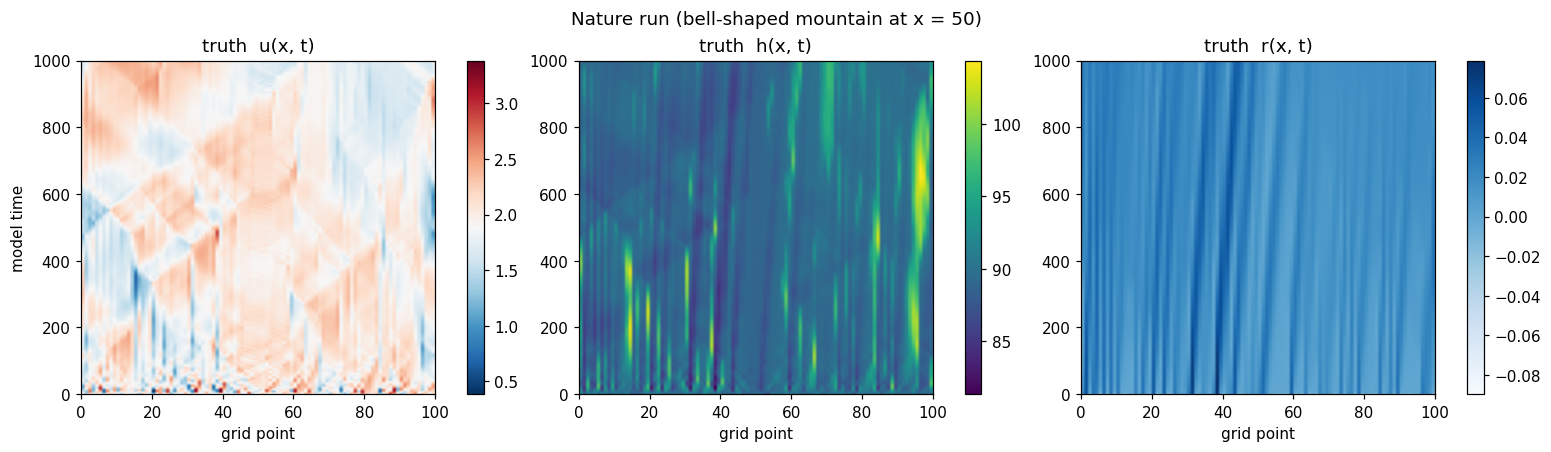

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
extent = [0, n, 0, tseq.T]
for ax, f, cmap in zip(axs, FIELDS, ["RdBu_r", "viridis", "Blues"]):
    im = ax.imshow(xx[:, SLICES[f]], aspect="auto", origin="lower",
                   extent=extent, cmap=cmap)
    ax.set_title(f"truth  {f}(x, t)"); ax.set_xlabel("grid point")
    fig.colorbar(im, ax=ax)
axs[0].set_ylabel("model time")
fig.suptitle("Nature run (bell-shaped mountain at x = 50)")
plt.show()

## 3 · LETKF

Local Ensemble Transform Kalman Filter: $N=50$ members, Gaspari–Cohn localization with
radius 4, no extra inflation. The background covariance is **flow-dependent** (from the ensemble).

In [5]:
dp.set_seed(3000)
xp_letkf = da.LETKF(N=nens, loc_rad=loc_radius, infl=infl_factor, rot=True)
xp_letkf.assimilate(HMM, xx, yy)
print("LETKF done.")

LETKF:   0%|          | 0/1000 [00:00<?, ?it/s]

LETKF done.

## 4 · 3D-Var with two static background covariances

3D-Var uses a **fixed** $B$. We compare two choices:

* **Gauss B** — block-diagonal: each field gets its climatological variance times a periodic
  Gaussian correlation ($L=5$). *No cross-variable terms*, so an $h$ observation cannot
  directly correct $u$ or $r$.
* **clim B** — the sample covariance of the nature run, tapered by the same Gaussian
  correlation. This **retains static $u$–$h$–$r$ cross-covariances**, letting $h$ obs nudge
  the unobserved fields (the Schur product of two PSD matrices stays PSD).

In [6]:
L_B = 5.0
field_vars = [np.var(xx[:, SLICES[f]]) for f in FIELDS]
print("climatological field variances (u, h, r):", np.round(field_vars, 5))

# --- Gauss B : block-diagonal ---
C = periodic_gauss_corr(n, L_B)
B_gauss = np.zeros((3*n, 3*n))
for k, f in enumerate(FIELDS):
    B_gauss[k*n:(k+1)*n, k*n:(k+1)*n] = field_vars[k] * C

# --- clim B : tapered sample covariance (keeps cross-covariances) ---
kburn  = int(tseq.BurnIn / tseq.dt)
B_clim = np.cov(xx[kburn:].T) * np.tile(C, (3, 3))

climatological field variances (u, h, r):

[5.72000e-02 7.45238e+00 1.30000e-04]

### 4.1 · Run 3D-Var (Gauss B)

In [7]:
dp.set_seed(3000)
xp_3dvar_g = da.Var3D(B=B_gauss, xB=1.0)
xp_3dvar_g.assimilate(HMM, xx, yy)
print("3D-Var (Gauss B) done.")

Var3D:   0%|          | 0/1000 [00:00<?, ?it/s]

3D-Var (Gauss B) done.

### 4.2 · Run 3D-Var (clim B)

In [8]:
dp.set_seed(3000)
xp_3dvar_c = da.Var3D(B=B_clim, xB=1.0)
xp_3dvar_c.assimilate(HMM, xx, yy)
print("3D-Var (clim B) done.")

experiments = {"LETKF": xp_letkf,
               "3DVar (Gauss B)": xp_3dvar_g,
               "3DVar (clim B)": xp_3dvar_c}

Var3D:   0%|          | 0/1000 [00:00<?, ?it/s]

3D-Var (clim B) done.

## 5 · Diagnostics

### 5.1 · Time-mean RMSE table (post burn-in)
Forecast (`_f`) and analysis (`_a`) RMSE for each field. Compare $h$ against the observation
error std below — a well-performing filter drives the analysis $h$ error below it.

In [9]:
rows = []
for name, xp in experiments.items():
    ef = rmse_per_field(xp.stats.err.f[mask])
    ea = rmse_per_field(xp.stats.err.a[mask])
    rows.append((name, ef, ea))

hdr = f"{'method':18s}" + "".join(f"{f+'_f':>9s}{f+'_a':>9s}" for f in FIELDS)
print(hdr); print("-" * len(hdr))
for name, ef, ea in rows:
    line = f"{name:18s}"
    for f in FIELDS:
        line += f"{ef[f].mean():9.4f}{ea[f].mean():9.4f}"
    print(line)

obs_err = sig[FIELDS.index(obs_var_name)]
print(f"\nobservation error std for '{obs_var_name}': {obs_err:.3f}")

method                  u_f      u_a      h_f      h_a      r_f      r_a

------------------------------------------------------------------------

LETKF                0.2116   0.2090   1.7929   1.7150   0.0062   0.0061

3DVar (Gauss B)      0.8337   0.8337   2.6663   2.5452   0.0211   0.0211

3DVar (clim B)       0.4251   0.4301   3.1700   3.1371   0.0108   0.0110


observation error std for 'h': 1.581

### 5.2 · RMSE over time, per field
Solid = analysis, dotted = forecast. Log scale; dashed black line marks the $h$ observation error.

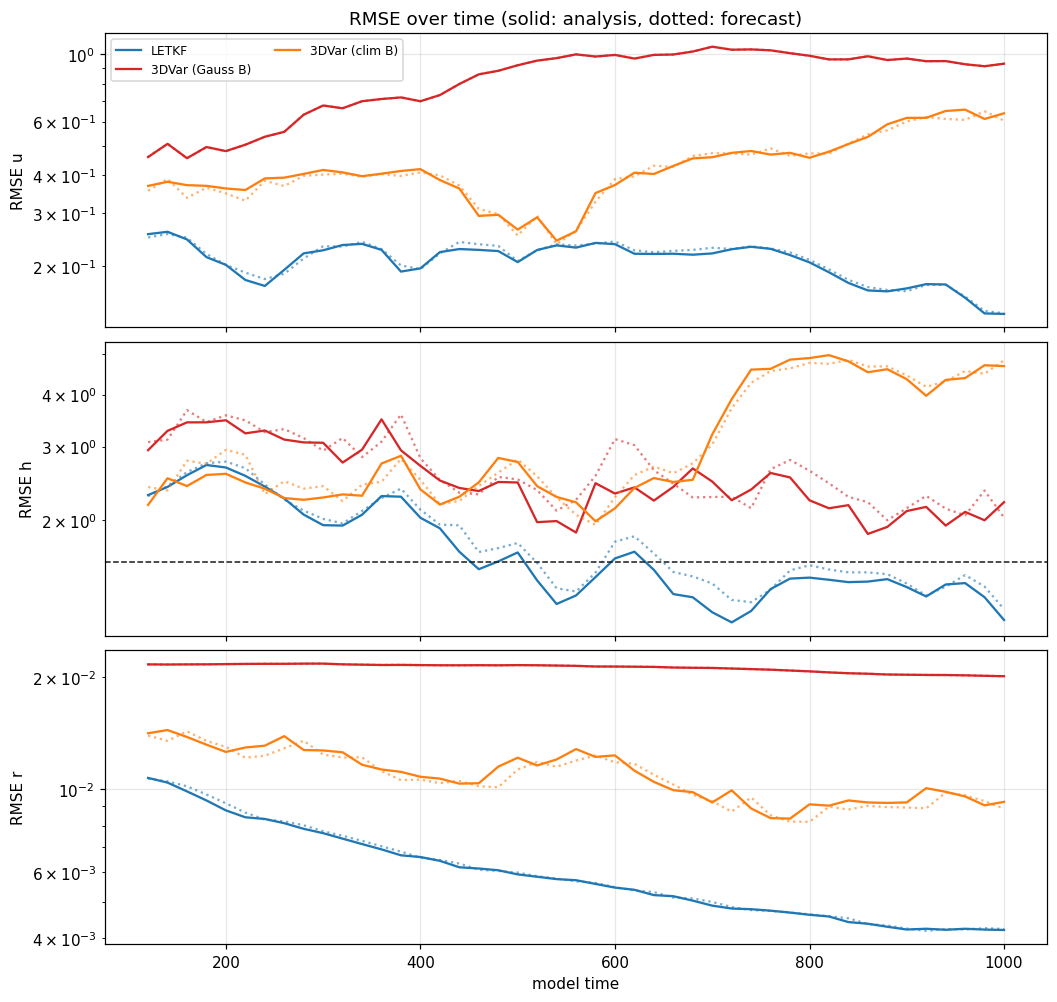

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(9.5, 9), sharex=True, constrained_layout=True)
for ax, f in zip(axs, FIELDS):
    for name, xp in experiments.items():
        ea = rmse_per_field(xp.stats.err.a[mask])[f]
        ef = rmse_per_field(xp.stats.err.f[mask])[f]
        ax.plot(tt_obs[mask], ef, ":", color=COLORS[name], alpha=0.6)
        ax.plot(tt_obs[mask], ea, "-", color=COLORS[name], label=f"{name}")
    if f == obs_var_name:
        ax.axhline(obs_err, color="k", ls="--", lw=1, label="obs error std")
    ax.set_ylabel(f"RMSE {f}"); ax.set_yscale("log"); ax.grid(alpha=0.3)
axs[0].legend(ncol=2, fontsize=8)
axs[0].set_title("RMSE over time (solid: analysis, dotted: forecast)")
axs[-1].set_xlabel("model time")
plt.show()

### 5.3 · LETKF spread–skill
For a well-calibrated ensemble the analysis **spread** should track the analysis **RMSE**
(ratio $\approx 1$). Ratio $<1$ → under-dispersive (needs more inflation); $>1$ → over-dispersive.

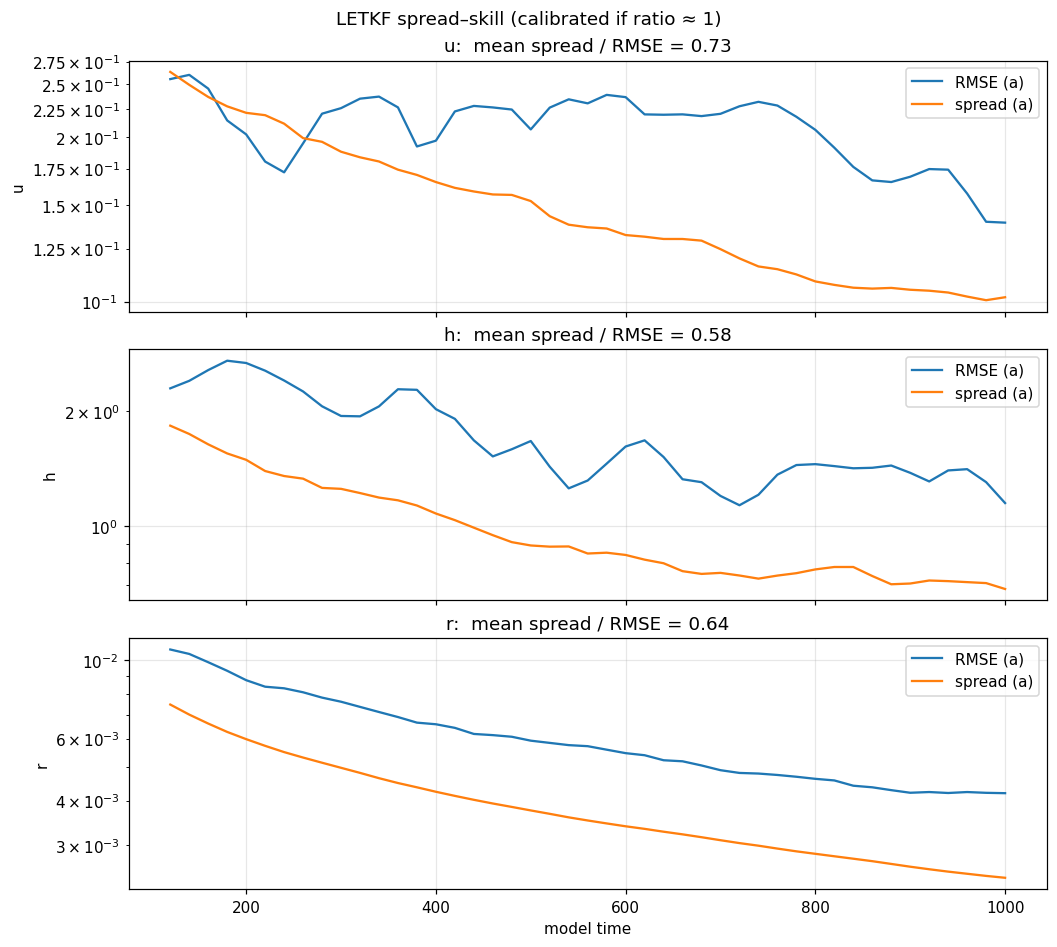

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(9.5, 8.5), sharex=True, constrained_layout=True)
sp_a = spread_per_field(xp_letkf.stats.spread.a[mask])
er_a = rmse_per_field(xp_letkf.stats.err.a[mask])
for ax, f in zip(axs, FIELDS):
    ax.plot(tt_obs[mask], er_a[f], label="RMSE (a)")
    ax.plot(tt_obs[mask], sp_a[f], label="spread (a)")
    ratio = sp_a[f].mean() / er_a[f].mean()
    ax.set_title(f"{f}:  mean spread / RMSE = {ratio:.2f}")
    ax.set_ylabel(f); ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend()
axs[-1].set_xlabel("model time")
fig.suptitle("LETKF spread–skill (calibrated if ratio ≈ 1)")
plt.show()

### 5.4 · Innovation statistics
Innovations $v_k = y_k - H\,\mathbf{x}^f_k$. An unbiased, consistent filter has
$E[v_k]\approx 0$ and $\mathrm{std}(v_k)\approx\sqrt{HP^fH^\top+R}$.

LETKF              mean = -0.0633   std = 1.8528

3DVar (Gauss B)    mean = +0.0207   std = 2.6987

3DVar (clim B)     mean = +0.2087   std = 2.1104

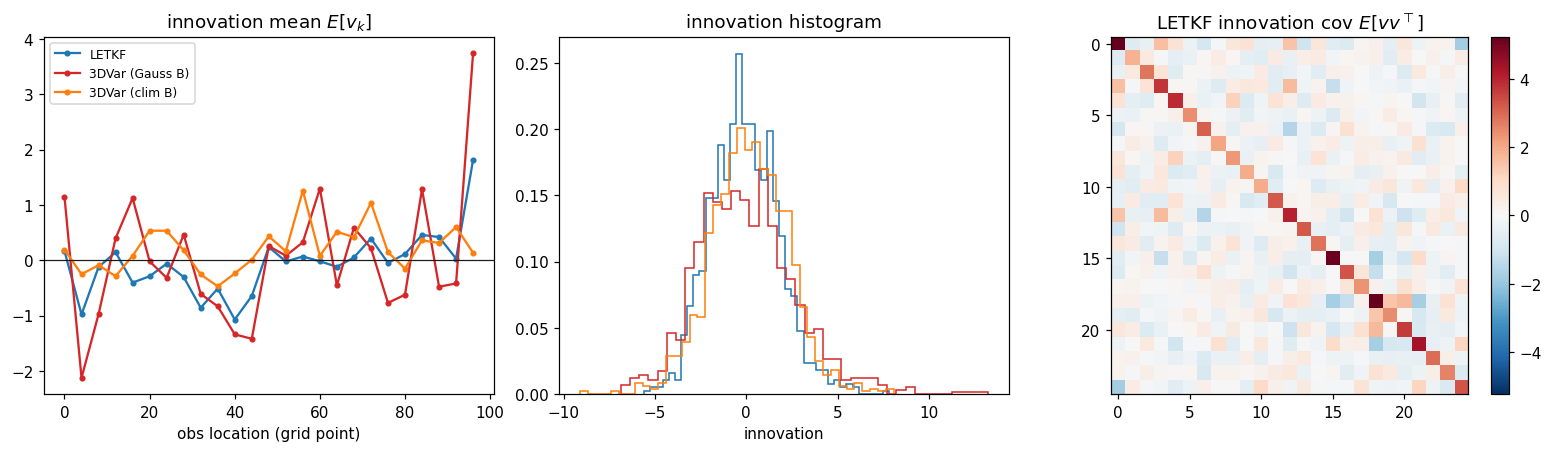

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
innov = {}
for name, xp in experiments.items():
    muf = xp.stats.mu.f[mask]
    v = yy[mask] - msw.hmod(muf)          # (Kpost, Ny)
    innov[name] = v
    axs[0].plot(np.arange(v.shape[1]) * nth_point, v.mean(0),
                "o-", ms=3, color=COLORS[name], label=name)
    axs[1].hist(v.ravel(), bins=40, density=True, histtype="step", color=COLORS[name])

for name, v in innov.items():
    print(f"{name:18s} mean = {v.mean():+.4f}   std = {v.std():.4f}")

axs[0].axhline(0, color="k", lw=0.8); axs[0].set_title(r"innovation mean $E[v_k]$")
axs[0].set_xlabel("obs location (grid point)"); axs[0].legend(fontsize=8)
axs[1].set_title("innovation histogram"); axs[1].set_xlabel("innovation")
Cvv = np.cov(innov["LETKF"].T)
m = np.abs(Cvv).max()
im = axs[2].imshow(Cvv, cmap="RdBu_r", vmin=-m, vmax=m)
axs[2].set_title(r"LETKF innovation cov $E[vv^\top]$"); fig.colorbar(im, ax=axs[2])
plt.show()

### 5.5 · Final-time snapshot: analyses vs truth
How closely each analysis mean matches the truth at the last cycle. Crosses = the assimilated $h$ observations.

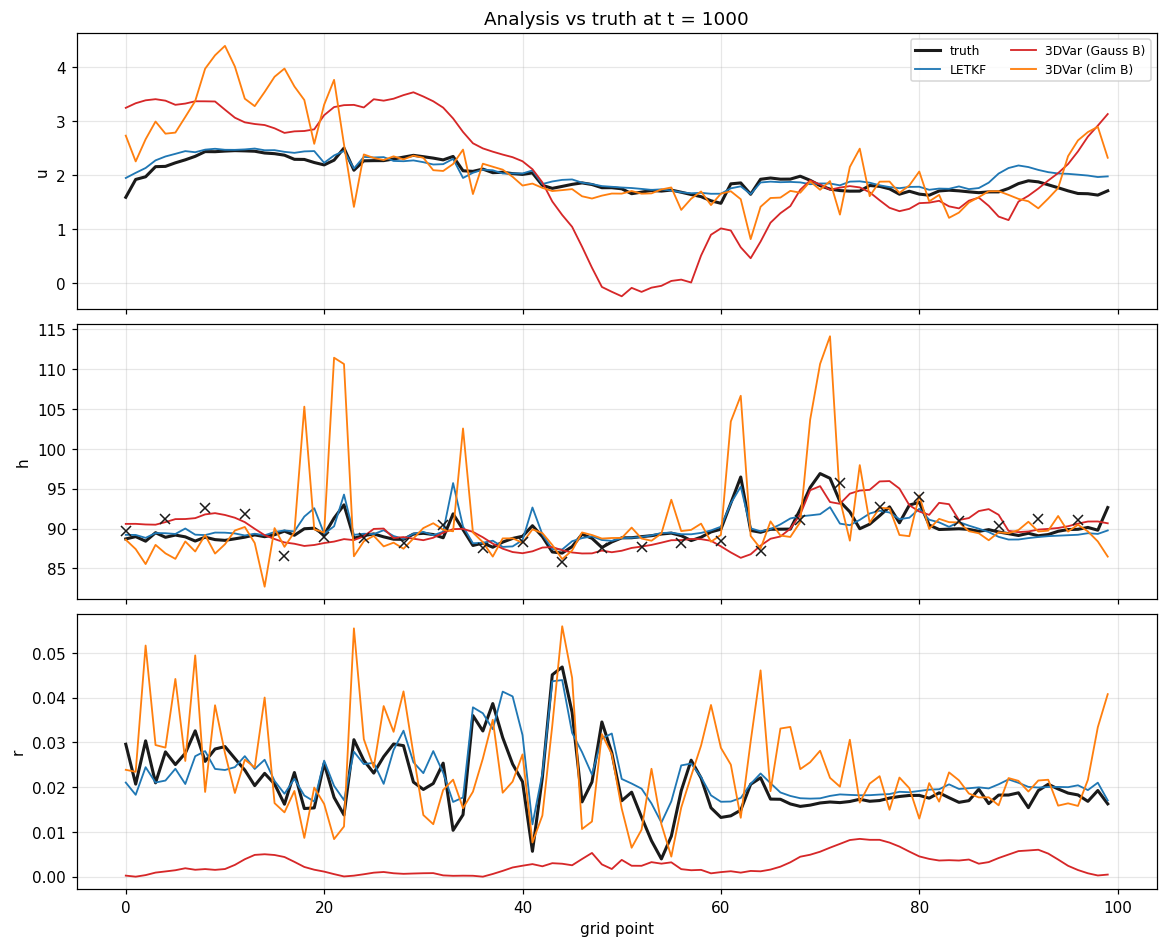

In [13]:
k_last = np.where(mask)[0][-1]
t_last = tt_obs[k_last]
k_full = int(round(t_last / tseq.dt))
xgrid  = np.arange(n)

fig, axs = plt.subplots(3, 1, figsize=(10.5, 8.5), sharex=True, constrained_layout=True)
for ax, f in zip(axs, FIELDS):
    ax.plot(xgrid, xx[k_full, SLICES[f]], "k-", lw=2, label="truth")
    for name, xp in experiments.items():
        ax.plot(xgrid, xp.stats.mu.a[k_last, SLICES[f]], color=COLORS[name], lw=1.2, label=name)
    if f == obs_var_name:
        ax.plot(msw.obs_coord, yy[k_last], "kx", ms=6, label="obs")
    ax.set_ylabel(f); ax.grid(alpha=0.3)
axs[0].legend(ncol=2, fontsize=8)
axs[0].set_title(f"Analysis vs truth at t = {t_last:.0f}")
axs[-1].set_xlabel("grid point")
plt.show()

### 5.6 · The two static $B$ correlation structures
Left: block-diagonal Gaussian (no cross-variable coupling). Right: localized climatology
(off-diagonal blocks encode $u$–$h$–$r$ correlations that let $h$ obs update $u$ and $r$).

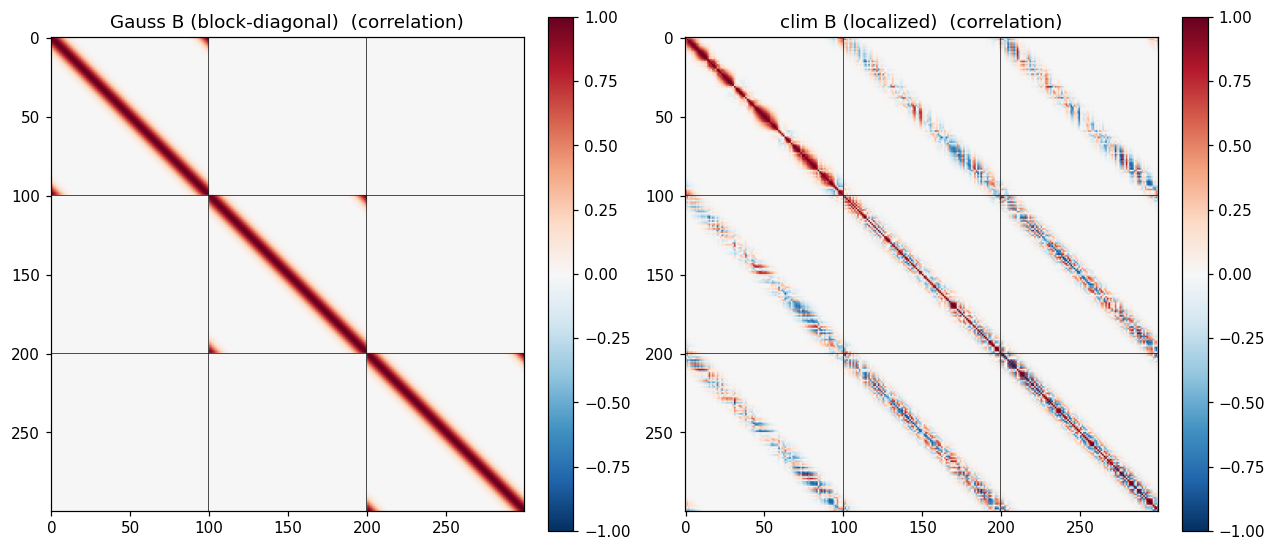

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(11.5, 5), constrained_layout=True)
for ax, (B, title) in zip(axs, [(B_gauss, "Gauss B (block-diagonal)"),
                                (B_clim,  "clim B (localized)")]):
    s = np.sqrt(np.abs(np.diag(B)))
    corr = B / np.outer(s, s); corr[~np.isfinite(corr)] = 0.0
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title + "  (correlation)")
    for k in (n, 2*n):
        ax.axhline(k-0.5, color="k", lw=0.5); ax.axvline(k-0.5, color="k", lw=0.5)
    fig.colorbar(im, ax=ax)
plt.show()

## 6 · Takeaways

* **LETKF wins across all three fields** and is the only method whose analysis $h$ error
  dips below the observation error — its flow-dependent, localized covariance spreads the
  $h$ information into $u$ and $r$ correctly.
* **3D-Var (Gauss B)** barely constrains the *unobserved* $u$ and $r$: with no cross-variable
  terms, the $h$ observations only touch $h$.
* **3D-Var (clim B)** recovers $u$ and $r$ better thanks to static cross-covariances, but the
  *fixed* $B$ eventually misfits $h$ once the flow departs from climatology.

### Suggested extensions (project sheet)
Re-run section 3 with sweeps and compare the RMSE table:
```python
for N in (20, 30, 50):
    for r in (3, 5, 10):
        for infl in (1.0, 1.02, 1.05):
            xp = da.LETKF(N=N, loc_rad=r, infl=infl, rot=True)
            xp.assimilate(HMM, xx, yy)
            ...
```
Change `obs_var_name` / `nth_point` in `constants.py` to test different observing systems
(e.g. observe $u$, or $h$ every 5th point) and their impact on the unobserved fields.